In [23]:
import torch
from torch import nn, einsum
import numpy as np
from einops import rearrange

import torch.nn.functional as f

In [24]:
class CyclicShift(nn.Module):
    def __init__(self, displacement):
        super().__init__()
        self.displacement = displacement
    def forward(self, x):
        return torch.roll(x, shifts=(self.displacement, self.displacement), dims=(1,2))

In [25]:
x = torch.linspace(1,81,81).view(9,9)
print(x)
y = torch.roll(input=x, shifts=(-1,-1), dims=(0,1))
print(y)

tensor([[ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9.],
        [10., 11., 12., 13., 14., 15., 16., 17., 18.],
        [19., 20., 21., 22., 23., 24., 25., 26., 27.],
        [28., 29., 30., 31., 32., 33., 34., 35., 36.],
        [37., 38., 39., 40., 41., 42., 43., 44., 45.],
        [46., 47., 48., 49., 50., 51., 52., 53., 54.],
        [55., 56., 57., 58., 59., 60., 61., 62., 63.],
        [64., 65., 66., 67., 68., 69., 70., 71., 72.],
        [73., 74., 75., 76., 77., 78., 79., 80., 81.]])
tensor([[11., 12., 13., 14., 15., 16., 17., 18., 10.],
        [20., 21., 22., 23., 24., 25., 26., 27., 19.],
        [29., 30., 31., 32., 33., 34., 35., 36., 28.],
        [38., 39., 40., 41., 42., 43., 44., 45., 37.],
        [47., 48., 49., 50., 51., 52., 53., 54., 46.],
        [56., 57., 58., 59., 60., 61., 62., 63., 55.],
        [65., 66., 67., 68., 69., 70., 71., 72., 64.],
        [74., 75., 76., 77., 78., 79., 80., 81., 73.],
        [ 2.,  3.,  4.,  5.,  6.,  7.,  8.,  9.,  1.]])


### c is number of channels

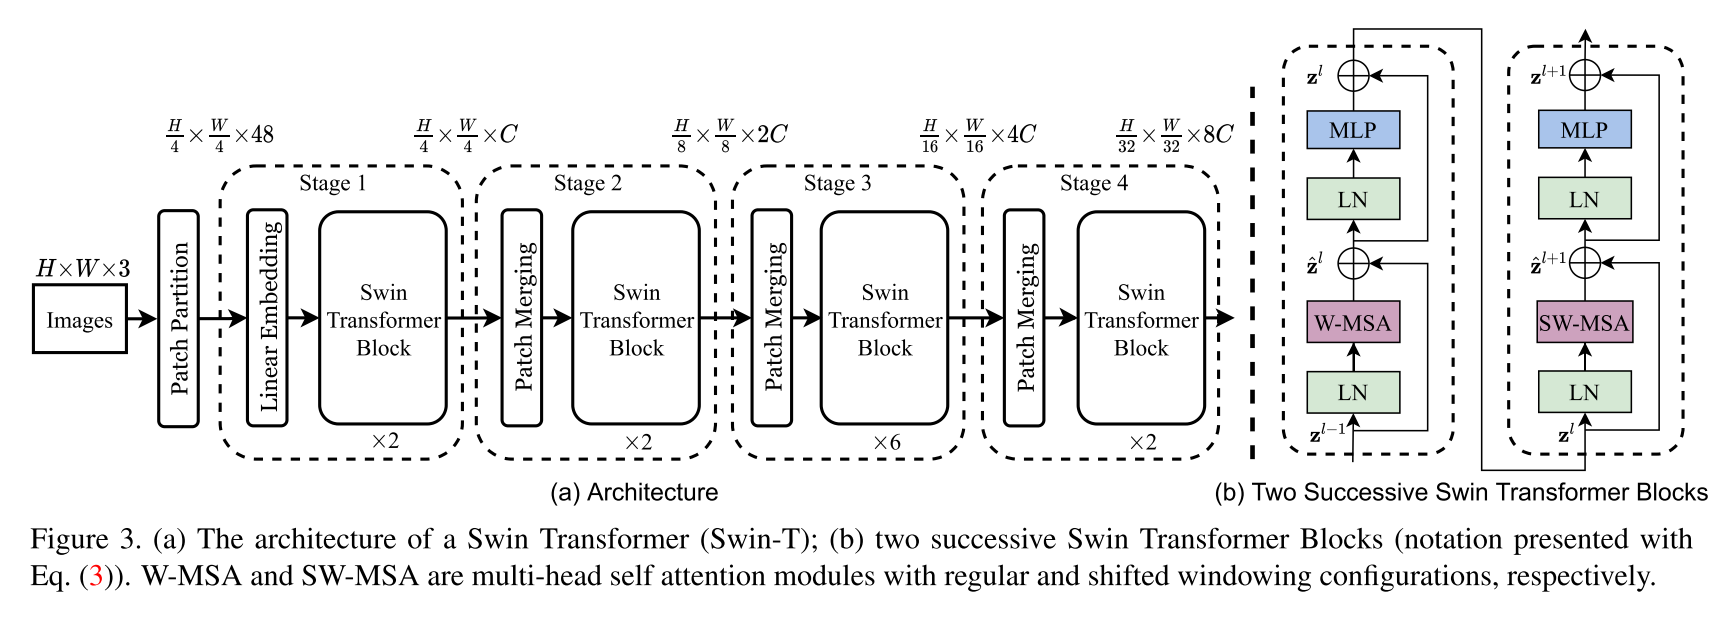

In [26]:
class Residual(nn.Module):
    def __init__(self, fn):
        super().__init__()
        self.fn =fn
    def forward(self, x, **kwargs):
        return self.fn(x, **kwargs) +x

In [27]:
torch.manual_seed(0)
B,H, W, C = 1,2,2,3
input = torch.randn(B,H,W,C)*100
print('input: ', input)
layer_norm = nn.LayerNorm(C)
output= layer_norm(input)
print('output: ', output)

input:  tensor([[[[ 154.0996,  -29.3429, -217.8789],
          [  56.8431, -108.4522, -139.8595]],

         [[  40.3347,   83.8026,  -71.9258],
          [ -40.3344,  -59.6635,   18.2036]]]])
output:  tensor([[[[ 1.2191,  0.0112, -1.2303],
          [ 1.3985, -0.5173, -0.8813]],

         [[ 0.3495,  1.0120, -1.3615],
          [-0.3948, -0.9787,  1.3735]]]], grad_fn=<NativeLayerNormBackward0>)


In [28]:
class PreNorm(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fn =fn
    def forward(self, x, **kwargs):
        return self.fn(self.norm(x), **kwargs)

In [29]:
class FeedForward(nn.Module):
    #mlp_dim = hidden_dim*4 where dim = hidden_dim= (96,192,384,768)
    def __init__(self, dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim,dim),
        )
    def forward(self, x):
        return self.net(x)

In [30]:
def get_relative_distances(window_size):
    indices = torch.tensor( np.array([[x,y] for x in range(window_size) for y in range(window_size)]))
    # print('ndices: ', indices.size())
    distance = indices[None, :, :] - indices[:, None, :]
    return distance

In [31]:
tmp  = get_relative_distances(window_size=3)
print(tmp.size())
print(tmp[:,:,1])
print(tmp[:,:,0])

torch.Size([9, 9, 2])
tensor([[ 0,  1,  2,  0,  1,  2,  0,  1,  2],
        [-1,  0,  1, -1,  0,  1, -1,  0,  1],
        [-2, -1,  0, -2, -1,  0, -2, -1,  0],
        [ 0,  1,  2,  0,  1,  2,  0,  1,  2],
        [-1,  0,  1, -1,  0,  1, -1,  0,  1],
        [-2, -1,  0, -2, -1,  0, -2, -1,  0],
        [ 0,  1,  2,  0,  1,  2,  0,  1,  2],
        [-1,  0,  1, -1,  0,  1, -1,  0,  1],
        [-2, -1,  0, -2, -1,  0, -2, -1,  0]])
tensor([[ 0,  0,  0,  1,  1,  1,  2,  2,  2],
        [ 0,  0,  0,  1,  1,  1,  2,  2,  2],
        [ 0,  0,  0,  1,  1,  1,  2,  2,  2],
        [-1, -1, -1,  0,  0,  0,  1,  1,  1],
        [-1, -1, -1,  0,  0,  0,  1,  1,  1],
        [-1, -1, -1,  0,  0,  0,  1,  1,  1],
        [-2, -2, -2, -1, -1, -1,  0,  0,  0],
        [-2, -2, -2, -1, -1, -1,  0,  0,  0],
        [-2, -2, -2, -1, -1, -1,  0,  0,  0]])


In [32]:
a = torch.tensor([1,2,3])
print('a: ', a)
print('size of a: ', a.size())
a1 =a[None, :]
print('a1: ', a1)
print('size of a1: ', a1.size())
a2 = a[:, None]
print('a2: ', a2)
print('size of a2: ', a2.size())
d = a1-a2
print('d: ',d)
print('size of d: ', d.size())

a:  tensor([1, 2, 3])
size of a:  torch.Size([3])
a1:  tensor([[1, 2, 3]])
size of a1:  torch.Size([1, 3])
a2:  tensor([[1],
        [2],
        [3]])
size of a2:  torch.Size([3, 1])
d:  tensor([[ 0,  1,  2],
        [-1,  0,  1],
        [-2, -1,  0]])
size of d:  torch.Size([3, 3])


In [33]:
#pos_embedding #(!3,13)
p = torch.tensor([[1,2], 
                  [3,4]])
print(p.size())
#relative_indices is (49,49,2)
r = torch.tensor([[[0,0], [0,0], [0,0]],
                  [[1,1],[1,1],[1,1]],
                  [[0,1],[0,1],[0,1]]])
print(r.size())
#self.pos_embedding[self.relative_indices[:,:,0], self.relative_indices[:,:,1]] #(49,49)
print(p[r[:,:,0], r[:,:,1]])

torch.Size([2, 2])
torch.Size([3, 3, 2])
tensor([[1, 1, 1],
        [4, 4, 4],
        [2, 2, 2]])


In [50]:
def create_mask(window_size, displacement, upper_lower, left_right):
    mask = torch.zeros(window_size**2, window_size**2)
    print('original mask: ', mask)
    if upper_lower:
        mask[-displacement*window_size:,:-displacement* window_size] = float('-inf')  #down left seletion
        mask[:-displacement * window_size, -displacement*window_size:] = float('-inf') # up right section
    if left_right:                  # to handle last vertical patches
        mask = rearrange(mask, '(h1 w1) (h2 w2) -> h1 w1 h2 w2', h1=window_size, h2= window_size)
        mask[:, -displacement:, :,:-displacement]=float('-inf')
        mask[:,:-displacement, :,-displacement:] = float('-inf')
        mask = rearrange(mask, 'h1 w1 h2 w2 -> (h1 w1) (h2 w2)')
    return mask

In [ ]:
class WindowAttention(nn.Module):
    def __init__(self, dim, heads, head_dim, shifted, window_size, relative_pos_embedding):
        # dim=hidden_dim=(96,192,384,768);
        # heads = num_heads = (3,6,12,24);
        #head_dim =32
        super().__init__()
        inner_dim= head_dim * heads #(32*3 =96, 32*6=192, 3*12=384, 32*24=768) = c
        self.heads = heads
        self.scale = head_dim ** -0.5  #scalling dot product inside the softmax
        self.window_size = window_size #window_size= 7
        self.relative_pos_embedding = relative_pos_embedding
        self.shifted = shifted

        self.tau = nn.Parameter(torch.tensor(0.01), requires_grad=True)

        if self.shifted :
            displacement = window_size // 2
            self.cyclic_shift = CyclicShift(-displacement)
            self.cyclic_back_shift = CyclicShift(displacement)

            #(49,49): masks are not learnable parameters; requires_gra =False;
            self.upper_lower_mask = nn.Parameter(create_mask(window_size=window_size, displacement=displacement,
                                                             upper_lower=True, left_right=False), requires_grad=False)
            self.left_right_mask = nn.Parameter(create_mask(window_size=window_size, displacement=displacement,
                                                            upper_lower=False, left_right=True), requires_grad=False)
        self.to_qkv = nn.Linear(dim, inner_dim*3, bias = False)
        # time complexity. 3(hwC**2 )
        # dim = (96,192,384,768) and (inner_dim = head_dim * heads); we can also use C*3 and gives us same thing
        if self.relative_pos_embedding:
            #self.relative_indices = get_relative_distances(window_size) + window_size -1
            #self.pos_embedding = nn.Parameter(torch.randn(2*window_size-1, 2*window_size-1))
            self.pos_embedding = nn.Parameter(
            torch.randn(1, heads, 1, window_size*window_size, window_size*window_size)
            )
            # (13,13) because if I am on one cell I have 6 possible relationship behind and after
        else:
            self.pos_embedding = nn.Parameter(torch.randn(1,heads,1,window_size**2, window_size**2)) #(49, 49)

        self.to_out = nn.Linear(inner_dim, dim)
        # inner_dim = head_dim * heads = C, dim = hidden_dim = (96,192,384,768)
    def forward(self, x):
        if self.shifted:
            #print('x size: ', x.size()) #(1,(56,28,14,7), (56,28,14,7), (96,192,384,768))
            x =self.cyclic_shift(x)
            #print(' x size: ', x.size()) #(1,(56,28,14,7), (56,28,14,7), (96,192,384,768))
        b, n_h, n_w, _, h = *x.shape, self.heads
        #print('x shape: ', x.shape)             #(1,(56,28,14,7), (56,28,14,7), (96,192,384,768))
        #print('self.to_qkv(x): ', self.to_qkv(x).size())        #(1,(56,28,14,7), (56,28,14,7), (288,576,1152,2304))

        qkv = self.to_qkv(x).chunk(3, dim =-1)
        #print ('qvk:', qkv[0].size())
        # (1, (56,28,14,7) (56,28,14,7), (96,192,384, 768)) for qkv[0] as qkv is a tuple

        nw_h = n_h // self.window_size #(56//7=8, 28//7 =4, 14//7 =2, 7//7 =1) 
        nw_w = n_w // self.window_size #(56//7=8, 28//7 =4, 14//7 =2, 7//7 =1) 

        q, k, v = map(
            lambda t: rearrange(t, 'b (nw_h w_h) (nw_w w_w) (h d)-> b h (nw_h nw_w)(w_h w_w) d',
                                h=h, w_h=self.window_size, w_w = self.window_size), qkv
        )
        #print('q size: ', q.size())
        # (b=1, h =(3,6,12,24), (nw_h*nw_w)= (64,16,4,1), (w_h*w_w)=49, d=32) where d+head_dim; h=#heads: 
        # print('k size: ', k.size())  # same as q
        # print('v size: ', v.size())  # same as q   
        # dot rpoduct similarity
        dots = einsum('b h w i d, b h w j d -> b h w i j', q,k ) * self.scale
        # b= batch_size, h =#heads (3,6,12,24), w = (64,16,4,1), i=49, j=49      

        dots += self.pos_embedding
        # b =batch_size, h = #head(3,6,12,24), w = (64,16,4,1), i =49, j =49

        if self.shifted:
            #temp1=self.upper_lower_mask #(49,49)
            #temp2 = self.left_right_mask  #(49,49)

            dots[:,:,-nw_w:] += self.upper_lower_mask
            dots[:,:,nw_w -1 :: nw_w]+= self.left_right_mask

        attn = dots.softmax(dim=-1)
        #b= batch_size, h=#heads(3,6,12,24), w=(64,16,4,1), i=49, j=49

        out = einsum('b h w i j, b h w j d-> b h w i d', attn, v)
        #(b=1, h=(3,6,12,24), (nw_h*nw_w)= (64,16,4,1), (w_h*w_w)=49, d=32) where d=head_dim; h = heads;

        out = rearrange(out, 'b h (nw_h nw_w) (w_h w_w) d -> b (nw_h w_h)(nw_w w_w) (h d)',
                        h =h, w_h=self.window_size, w_w=self.window_size, nw_h= nw_h, nw_w= nw_w)
        #(1, (56,28,14,7), (56,28,14,7), (96192,384,768))

        out = self.to_out(out) #(1,(56,28,14,7), (56,28,14,7), (96,192,384,768))

        if self.shifted:
            out = self.cyclic_back_shift(out) #(1,(56,28,14,7), (56,28,14,7), (96,192,384,768))

        return out

In [52]:
do = torch.rand(1,1,2,5,5)
print('do: ',do)
mo = torch.ones(5,5)
print('do: ', mo)
do[:,:,1]= do[:,:,1]+mo
print('do3: ', do)

do:  tensor([[[[[0.5071, 0.4895, 0.1602, 0.1338, 0.5957],
           [0.4654, 0.8634, 0.4615, 0.4861, 0.4185],
           [0.4139, 0.1889, 0.7856, 0.8748, 0.5395],
           [0.7772, 0.8823, 0.1789, 0.0185, 0.1601],
           [0.4808, 0.1930, 0.7229, 0.9189, 0.7301]],

          [[0.3860, 0.2377, 0.1203, 0.7788, 0.7420],
           [0.4402, 0.4455, 0.4280, 0.5911, 0.3108],
           [0.0562, 0.3570, 0.0482, 0.1895, 0.3872],
           [0.0672, 0.4268, 0.6618, 0.0922, 0.0855],
           [0.9756, 0.9194, 0.5383, 0.8159, 0.4365]]]]])
do:  tensor([[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]])
do3:  tensor([[[[[0.5071, 0.4895, 0.1602, 0.1338, 0.5957],
           [0.4654, 0.8634, 0.4615, 0.4861, 0.4185],
           [0.4139, 0.1889, 0.7856, 0.8748, 0.5395],
           [0.7772, 0.8823, 0.1789, 0.0185, 0.1601],
           [0.4808, 0.1930, 0.7229, 0.9189, 0.7301]],

          [[1.3860, 1.2377, 1.

In [53]:
do = torch.rand(1,1,2,5,5)
print('do: ', do)
po = torch.ones(5,5)
print('do: ', po)
su = do + po
print('do3: ', su)

do:  tensor([[[[[0.8981, 0.3705, 0.7965, 0.7914, 0.5655],
           [0.4986, 0.5947, 0.4019, 0.2458, 0.1655],
           [0.6227, 0.6617, 0.0359, 0.8079, 0.2292],
           [0.8570, 0.9451, 0.1432, 0.5698, 0.5070],
           [0.3627, 0.0194, 0.7496, 0.9889, 0.7848]],

          [[0.3447, 0.6642, 0.7541, 0.6455, 0.5568],
           [0.8241, 0.1579, 0.4130, 0.2859, 0.3563],
           [0.6710, 0.6766, 0.6411, 0.6884, 0.0288],
           [0.6812, 0.7498, 0.0041, 0.2571, 0.4735],
           [0.0060, 0.8768, 0.2558, 0.4839, 0.3400]]]]])
do:  tensor([[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]])
do3:  tensor([[[[[1.8981, 1.3705, 1.7965, 1.7914, 1.5655],
           [1.4986, 1.5947, 1.4019, 1.2458, 1.1655],
           [1.6227, 1.6617, 1.0359, 1.8079, 1.2292],
           [1.8570, 1.9451, 1.1432, 1.5698, 1.5070],
           [1.3627, 1.0194, 1.7496, 1.9889, 1.7848]],

          [[1.3447, 1.6642, 1.

In [54]:
create_mask(window_size=3, displacement=1, upper_lower=False, left_right=True)

original mask:  tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.]])


tensor([[0., 0., -inf, 0., 0., -inf, 0., 0., -inf],
        [0., 0., -inf, 0., 0., -inf, 0., 0., -inf],
        [-inf, -inf, 0., -inf, -inf, 0., -inf, -inf, 0.],
        [0., 0., -inf, 0., 0., -inf, 0., 0., -inf],
        [0., 0., -inf, 0., 0., -inf, 0., 0., -inf],
        [-inf, -inf, 0., -inf, -inf, 0., -inf, -inf, 0.],
        [0., 0., -inf, 0., 0., -inf, 0., 0., -inf],
        [0., 0., -inf, 0., 0., -inf, 0., 0., -inf],
        [-inf, -inf, 0., -inf, -inf, 0., -inf, -inf, 0.]])

down scaling factor
    4	2	2	2
layers              
    2	2	6	2
o/t: hidden_dim.  
    C=96	2c=192	4C=384	8c= 768
Input_channel 
    3 	C=96 	2c=192	4c=384
c:hidden_dim.
    96	96	96	96
head_dim 
    32	32	32	32
#heads	3	6	12	24


In [39]:
class SwinBlock(nn.Module):
    def __init__(self, dim, heads, head_dim, mlp_dim, shifted, window_size, relative_pos_embedding):
        super().__init__()
        self.attention_block = Residual(PreNorm(dim, WindowAttention(dim=dim,
                                                                     heads= heads,
                                                                     head_dim=head_dim,
                                                                     shifted=shifted,
                                                                     window_size= window_size,
                                                                     relative_pos_embedding=relative_pos_embedding)))
        self.mlp_block = Residual(PreNorm(dim, FeedForward(dim=dim, hidden_dim=mlp_dim)))
    def forward(self,x):
        x =self.attention_block(x) # (1,(56,28,14,7), (56,28,14,7), (96,192,384,768))
        x= self.mlp_block(x) # (1,(56,28,14,7), (56,28,14,7), (96,192,384,768))
        return x
        

In [40]:
class PatchMerging_Conv(nn.Module):
    def __init__(self, in_channels, out_channels, downscaling_factor):
        super().__init__()
        self.patch_merge = nn.Conv2d(
            in_channels, out_channels, kernel_size= downscaling_factor,
            stride = downscaling_factor, padding=0
        )
    def forward(self, x):
        x = self.patch_merge(x).permute(0,2,3,1)
        return x

In [41]:
class StageModule(nn.Module):
    def __init__(self, in_channels, hidden_dimension, layers, downscaling_factor, num_heads, head_dim,
                 window_size, relative_pos_embedding):
        super().__init__()
        assert layers % 2 ==0, 'Stage layers need to be divisible by 2 for regular and shifted block.'
        self.patch_partition = PatchMerging_Conv(in_channels=in_channels, out_channels= hidden_dimension,
                                                 downscaling_factor= downscaling_factor)
        self.layers = nn.ModuleList([])
        for _ in range(layers//2):
            self.layers.append(nn.ModuleList([
                SwinBlock(dim=hidden_dimension, heads= num_heads, head_dim= head_dim, mlp_dim = hidden_dimension*4,
                          shifted=False, window_size=window_size, relative_pos_embedding= relative_pos_embedding),
                SwinBlock(dim=hidden_dimension, heads= num_heads, head_dim= head_dim, mlp_dim = hidden_dimension*4,
                          shifted=True, window_size=window_size, relative_pos_embedding= relative_pos_embedding)
            ]))

    def forward(self, x):
        x =self.patch_partition(x)
        for regular_block, shifted_block in self.layers:
            x =regular_block(x)
            x= shifted_block(x)
        return x.permute(0,3,1,2)

In [42]:
class SwinTransformer(nn.Module):
    def __init__(self, *, hidden_dim, layers, heads, channels=3, num_classes=1000, head_dim=32, window_size=7,
                 downscaling_factors=(4,2,2,2), relative_pos_embedding=True):
        super().__init__()
        self.stage1 = StageModule(in_channels= channels, hidden_dimension=hidden_dim, layers= layers[0],
                                  downscaling_factor = downscaling_factors[0], num_heads= heads[0], head_dim=head_dim,
                                  window_size=window_size, relative_pos_embedding=relative_pos_embedding)
        self.stage2 = StageModule(in_channels= hidden_dim, hidden_dimension=hidden_dim*2, layers= layers[1],
                                  downscaling_factor = downscaling_factors[1], num_heads= heads[1], head_dim=head_dim,
                                  window_size=window_size, relative_pos_embedding=relative_pos_embedding)
        self.stage3 = StageModule(in_channels= hidden_dim*2, hidden_dimension=hidden_dim*4, layers= layers[2],
                                  downscaling_factor = downscaling_factors[2], num_heads= heads[2], head_dim=head_dim,
                                  window_size=window_size, relative_pos_embedding=relative_pos_embedding)
        self.stage4 = StageModule(in_channels= hidden_dim*4, hidden_dimension=hidden_dim*8, layers= layers[3],
                                  downscaling_factor = downscaling_factors[3], num_heads= heads[3], head_dim=head_dim,
                                  window_size=window_size, relative_pos_embedding=relative_pos_embedding)
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(hidden_dim*8),
            nn.Linear(hidden_dim*8, num_classes)
        )
    def forward(self, img):
        x = self.stage1(img)
        x=self.stage2(x)
        x = self.stage3(x)
        x= self.stage4(x) #(batch 768,7,7)
        x = x.mean(dim=[2,3]) #(batch, 1, 768)
        return self.mlp_head(x)

In [43]:
def swin_t(hidden_dim=96, layers=(2,2,6,2), heads = (3,6,12, 24), **kwargs):
    return SwinTransformer(hidden_dim=hidden_dim, layers=layers, heads=heads, **kwargs)

In [49]:
net = swin_t(
    hidden_dim=96,
    layers=(2,2,6,2),
    heads=(3,6,12,24),
    channels = 3,
    num_classes=3,
    head_dim = 32,
    window_size=7,
    downscaling_factors=(4,2,2,2),
    relative_pos_embedding= True
)
dummy_x= torch.randn(1,3,224,224)
logits = net(dummy_x) #(1,3)
print(logits)

original mask:  tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
original mask:  tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
original mask:  tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
original mask:  tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
 

In [46]:
a = torch.tensor([[[1,3], [2,2], [1,1]],
                  [[1,4], [3,6], [5,6]],
                  [[9,1],[2,8], [9,7]]])
print(a)
print(a.size())
a =a.float()
a=f.normalize(a, p=2, dim=-1)
print(a)
print(a.size())

tensor([[[1, 3],
         [2, 2],
         [1, 1]],

        [[1, 4],
         [3, 6],
         [5, 6]],

        [[9, 1],
         [2, 8],
         [9, 7]]])
torch.Size([3, 3, 2])
tensor([[[0.3162, 0.9487],
         [0.7071, 0.7071],
         [0.7071, 0.7071]],

        [[0.2425, 0.9701],
         [0.4472, 0.8944],
         [0.6402, 0.7682]],

        [[0.9939, 0.1104],
         [0.2425, 0.9701],
         [0.7894, 0.6139]]])
torch.Size([3, 3, 2])
